# Assignment 7: Creating and Fixing Mode Collapse in a GAN

**Objective:** To understand mode collapse in GANs by deliberately making the DCGAN from Assignment 4 unstable, observing the generated images, and then applying a technique to improve the training.

## Step 1: Importing Libraries

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

## Step 2: Basic Parameters
Most parameters are the same as Assignment 4. The epochs are reduced to 20, as the assignment asks for 15 to 20 epochs. A second, much higher learning rate is added, which will be used to make the model unstable.

In [3]:
NOISE_SIZE = 100          # size of the noise vector (input to generator)
BATCH_SIZE = 128
EPOCHS = 20
NORMAL_LR = 0.0002        # learning rate used in Assignment 4
BROKEN_LR = 0.001         # higher learning rate used to make training unstable
IMAGE_SIZE = 28
CHANNELS = 1

# Fixing the seed so the same fixed noise is used in both runs
torch.manual_seed(42)

# Fixed noise vector so the broken and the improved model can be compared on the same inputs
FIXED_NOISE = torch.randn(16, NOISE_SIZE, 1, 1)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

FIXED_NOISE = FIXED_NOISE.to(device)

Using device: cuda


## Step 3: Load Fashion-MNIST Dataset

The dataset and the normalisation are the same as Assignment 4. Images are brought to the range [-1, +1] because the generator uses tanh as its final activation.

In [4]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))   # brings pixel values from [0,1] to [-1,+1]
])

dataset = torchvision.datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

dataloader = torch.utils.data.DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

print(f"Total training images: {len(dataset)}")

100%|██████████| 26.4M/26.4M [00:02<00:00, 12.9MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 203kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.84MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 20.4MB/s]

Total training images: 60000


Displaying a 4x4 grid of real images. This is the reference for how good the generated images should look.

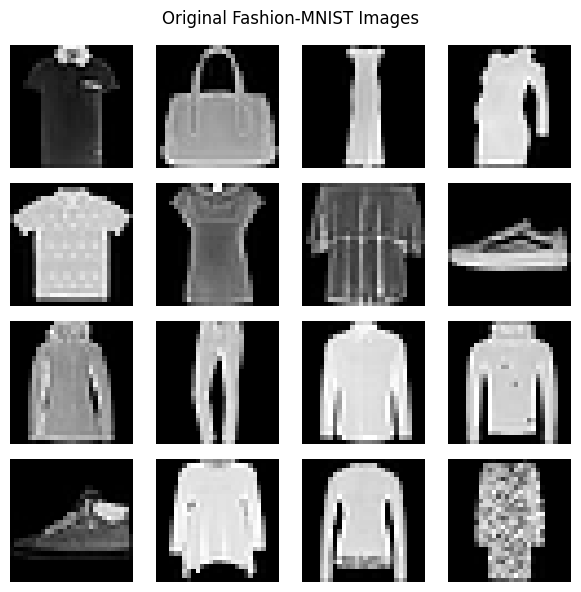

In [5]:
real_images, labels = next(iter(dataloader))

plt.figure(figsize=(6, 6))
for i in range(16):
    plt.subplot(4, 4, i+1)
    img = real_images[i].squeeze().numpy()
    img = (img + 1) / 2        # back to [0,1] for display
    plt.imshow(img, cmap='gray')
    plt.axis('off')
plt.suptitle('Original Fashion-MNIST Images')
plt.tight_layout()
plt.show()

## Step 4: Building the Generator and Discriminator

The architecture is the same as Assignment 4, except that the generator now has a switch for BatchNorm. For the broken model, BatchNorm is turned off in the generator. The discriminator is not changed.

In [6]:
class Generator(nn.Module):
    def __init__(self, use_batchnorm=True):
        super(Generator, self).__init__()

        # BatchNorm layers are only added when use_batchnorm is True
        def block(in_ch, out_ch, kernel, stride, padding):
            layers = [nn.ConvTranspose2d(in_ch, out_ch, kernel_size=kernel, stride=stride, padding=padding)]
            if use_batchnorm:
                layers.append(nn.BatchNorm2d(out_ch))
            layers.append(nn.ReLU())
            return layers

        self.model = nn.Sequential(
            *block(100, 256, 4, 1, 0),    # → (256, 4, 4)
            *block(256, 128, 4, 2, 1),    # → (128, 8, 8)
            *block(128, 64, 4, 2, 1),     # → (64, 16, 16)

            nn.ConvTranspose2d(64, 1, kernel_size=4, stride=2, padding=3),   # → (1, 28, 28)
            nn.Tanh()
        )

    def forward(self, x):
        return self.model(x)

In [7]:
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()

        self.model = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=4, stride=2, padding=1),     # → (64, 14, 14)
            nn.LeakyReLU(0.2),

            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),   # → (128, 7, 7)
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),

            nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1),  # → (256, 4, 4)
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2),

            nn.Conv2d(256, 1, kernel_size=4, stride=1, padding=0),    # → (1, 1, 1)
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x).view(-1, 1).squeeze(1)

In [8]:
# Broken model: generator WITHOUT BatchNorm
generator_broken = Generator(use_batchnorm=False).to(device)
discriminator_broken = Discriminator().to(device)

print(generator_broken)
print(discriminator_broken)

Generator(
  (model): Sequential(
    (0): ConvTranspose2d(100, 256, kernel_size=(4, 4), stride=(1, 1))
    (1): ReLU()
    (2): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (5): ReLU()
    (6): ConvTranspose2d(64, 1, kernel_size=(4, 4), stride=(2, 2), padding=(3, 3))
    (7): Tanh()
  )
)
Discriminator(
  (model): Sequential(
    (0): Conv2d(1, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): LeakyReLU(negative_slope=0.2)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2)
    (5): Conv2d(128, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (6): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): LeakyReLU(negative_slope=0.2)
    (8): C

## Step 5: Training Function

The same training loop from Assignment 4 is put inside a function, so the broken model and the improved model can be trained with exactly the same code. Only the learning rate and the real label value are passed in as settings. A 4x4 grid of images is saved every 5 epochs using the same fixed noise.

In [9]:
def show_grid(images, title, filename=None):
    plt.figure(figsize=(6, 6))
    for i in range(16):
        plt.subplot(4, 4, i+1)
        img = images[i].squeeze().cpu().numpy()
        img = (img + 1) / 2          # back to [0,1] for display
        plt.imshow(img, cmap='gray', vmin=0, vmax=1)
        plt.axis('off')
    plt.suptitle(title)
    plt.tight_layout()
    if filename:
        plt.savefig(filename)
    plt.show()

In [10]:
def train_gan(generator, discriminator, lr, real_label_value=1.0, run_name="run"):

    loss_function = nn.BCELoss()
    optimizer_G = optim.Adam(generator.parameters(), lr=lr, betas=(0.5, 0.999))
    optimizer_D = optim.Adam(discriminator.parameters(), lr=lr, betas=(0.5, 0.999))

    G_losses = []
    D_losses = []

    for epoch in range(1, EPOCHS + 1):

        g_loss_epoch = 0
        d_loss_epoch = 0

        for real_images, _ in dataloader:

            real_images = real_images.to(device)
            batch_size  = real_images.size(0)

            # label for real images seen by the discriminator (1.0 normally, 0.9 with label smoothing)
            real_labels_d = torch.full((batch_size,), real_label_value).to(device)
            # the generator always tries to get the label 1
            real_labels_g = torch.ones(batch_size).to(device)
            fake_labels   = torch.zeros(batch_size).to(device)

            # -------- Train Discriminator --------
            optimizer_D.zero_grad()

            output_real = discriminator(real_images)
            loss_real = loss_function(output_real, real_labels_d)

            noise = torch.randn(batch_size, NOISE_SIZE, 1, 1).to(device)
            fake_images = generator(noise)

            output_fake = discriminator(fake_images.detach())
            loss_fake = loss_function(output_fake, fake_labels)

            d_loss = loss_real + loss_fake
            d_loss.backward()
            optimizer_D.step()

            # -------- Train Generator --------
            optimizer_G.zero_grad()

            output_fake_for_g = discriminator(fake_images)
            g_loss = loss_function(output_fake_for_g, real_labels_g)

            g_loss.backward()
            optimizer_G.step()

            g_loss_epoch += g_loss.item()
            d_loss_epoch += d_loss.item()

        avg_g = g_loss_epoch / len(dataloader)
        avg_d = d_loss_epoch / len(dataloader)
        G_losses.append(avg_g)
        D_losses.append(avg_d)

        print(f"Epoch [{epoch}/{EPOCHS}]  Discriminator Loss: {avg_d:.4f}  Generator Loss: {avg_g:.4f}")

        # -------- Show and save 4x4 grid every 5 epochs --------
        if epoch % 5 == 0:
            generator.eval()
            with torch.no_grad():
                generated = generator(FIXED_NOISE)
            generator.train()
            show_grid(generated, f'{run_name}: Generated Images at Epoch {epoch}',
                      filename=f'{run_name}_epoch_{epoch}.png')

    return G_losses, D_losses

## Step 6: Training the Broken Model (No BatchNorm in Generator, High Learning Rate)

The generator without BatchNorm is trained for 20 epochs with the higher learning rate of 0.001, which is 5 times the Assignment 4 value. A grid of generated images is shown at epochs 5, 10, 15 and 20.

Epoch [1/20]  Discriminator Loss: 0.9910  Generator Loss: 2.4543
Epoch [2/20]  Discriminator Loss: 1.0292  Generator Loss: 1.8632
Epoch [3/20]  Discriminator Loss: 1.0219  Generator Loss: 1.8162
Epoch [4/20]  Discriminator Loss: 1.0284  Generator Loss: 1.8083
Epoch [5/20]  Discriminator Loss: 1.0279  Generator Loss: 1.7779


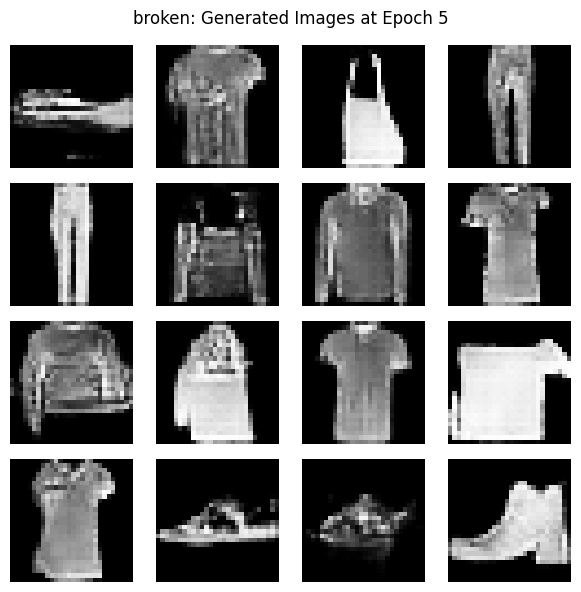

Epoch [6/20]  Discriminator Loss: 0.9821  Generator Loss: 1.8490
Epoch [7/20]  Discriminator Loss: 0.9592  Generator Loss: 1.8995
Epoch [8/20]  Discriminator Loss: 0.9191  Generator Loss: 1.9804
Epoch [9/20]  Discriminator Loss: 0.8959  Generator Loss: 2.0455
Epoch [10/20]  Discriminator Loss: 0.8353  Generator Loss: 2.1385


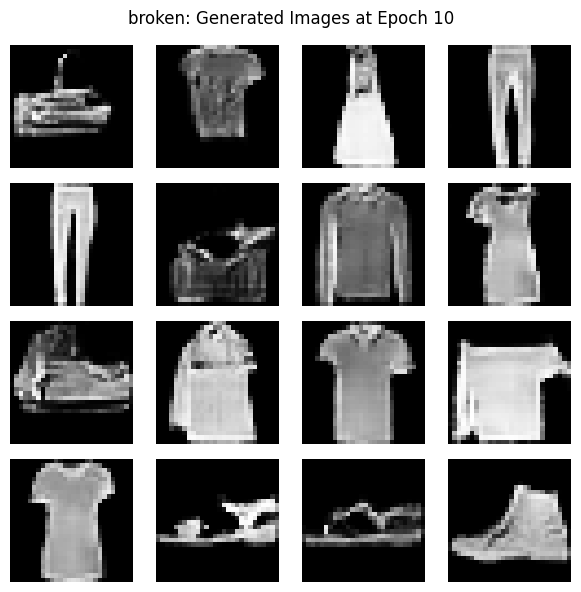

Epoch [11/20]  Discriminator Loss: 0.8356  Generator Loss: 2.1776
Epoch [12/20]  Discriminator Loss: 0.7963  Generator Loss: 2.2674
Epoch [13/20]  Discriminator Loss: 0.7593  Generator Loss: 2.3578
Epoch [14/20]  Discriminator Loss: 0.7164  Generator Loss: 2.4753
Epoch [15/20]  Discriminator Loss: 0.7143  Generator Loss: 2.5084


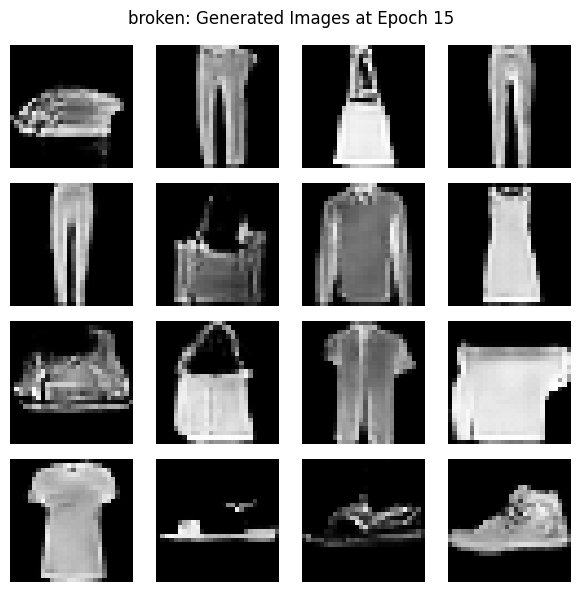

Epoch [16/20]  Discriminator Loss: 0.7037  Generator Loss: 2.6616
Epoch [17/20]  Discriminator Loss: 0.6411  Generator Loss: 2.6971
Epoch [18/20]  Discriminator Loss: 0.6568  Generator Loss: 2.7760
Epoch [19/20]  Discriminator Loss: 0.5688  Generator Loss: 2.8378
Epoch [20/20]  Discriminator Loss: 0.5831  Generator Loss: 2.9974


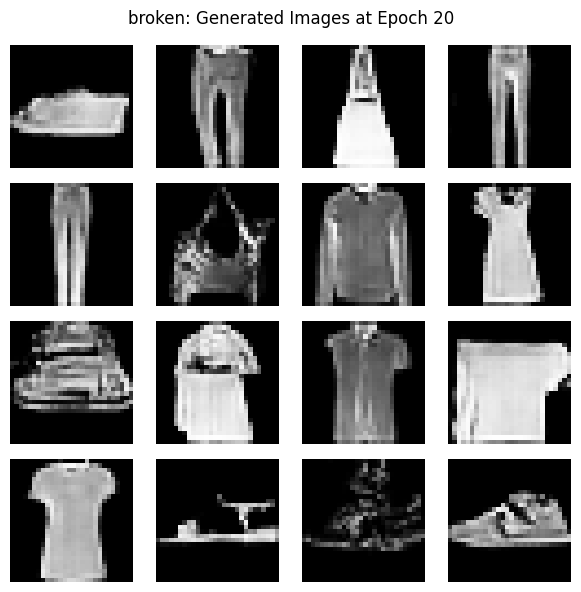

In [11]:
G_losses_broken, D_losses_broken = train_gan(
    generator_broken,
    discriminator_broken,
    lr=BROKEN_LR,
    real_label_value=1.0,
    run_name="broken"
)

##Plotting the generator and discriminator loss of the broken model.

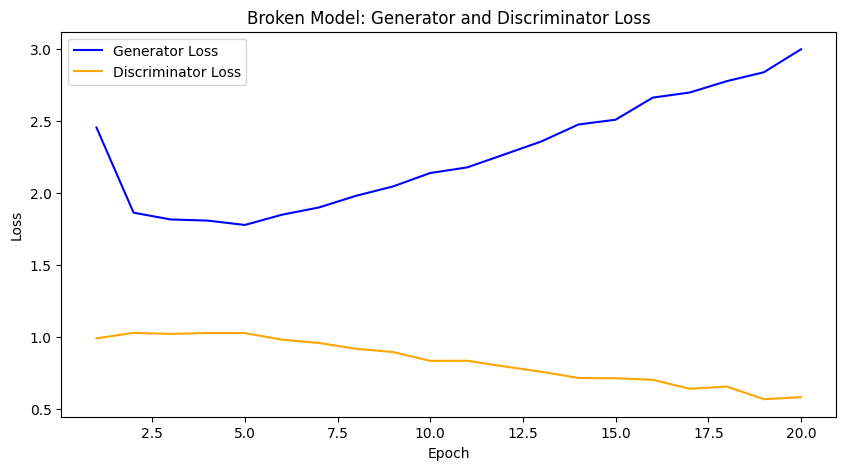

In [13]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, EPOCHS+1), G_losses_broken, label='Generator Loss',     color='blue')
plt.plot(range(1, EPOCHS+1), D_losses_broken, label='Discriminator Loss', color='orange')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Broken Model: Generator and Discriminator Loss')
plt.legend()
plt.show()

### Note on the First Attempt

In the first attempt (no BatchNorm in the generator, learning rate 0.001), the generator loss rose and the discriminator loss fell, but the generated images still showed many different clothing items. Mode collapse did not clearly happen, so a second, stronger attempt was made in Step 6B.

## Step 6B: Second Attempt at Breaking the Model

To make training more unstable, the generator capacity is now reduced as well. The number of filters is cut down to roughly one quarter of the original in each layer, BatchNorm stays removed, and the learning rate is increased to 0.005.

In [14]:
BROKEN_LR_2 = 0.005

class SmallGenerator(nn.Module):
    def __init__(self):
        super(SmallGenerator, self).__init__()

        # much fewer filters than the original generator (64, 32, 16 instead of 256, 128, 64), no BatchNorm
        self.model = nn.Sequential(
            nn.ConvTranspose2d(100, 64, kernel_size=4, stride=1, padding=0),   # → (64, 4, 4)
            nn.ReLU(),

            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),    # → (32, 8, 8)
            nn.ReLU(),

            nn.ConvTranspose2d(32, 16, kernel_size=4, stride=2, padding=1),    # → (16, 16, 16)
            nn.ReLU(),

            nn.ConvTranspose2d(16, 1, kernel_size=4, stride=2, padding=3),     # → (1, 28, 28)
            nn.Tanh()
        )

    def forward(self, x):
        return self.model(x)


generator_broken2 = SmallGenerator().to(device)
discriminator_broken2 = Discriminator().to(device)

# comparing the number of parameters of the two generators
params_original = sum(p.numel() for p in Generator(use_batchnorm=True).parameters())
params_small    = sum(p.numel() for p in generator_broken2.parameters())
print(f"Original generator parameters: {params_original}")
print(f"Reduced generator parameters : {params_small}")

Original generator parameters: 1067329
Reduced generator parameters : 143729


Epoch [1/20]  Discriminator Loss: 1.0517  Generator Loss: 3.0437
Epoch [2/20]  Discriminator Loss: 0.7509  Generator Loss: 3.0459
Epoch [3/20]  Discriminator Loss: 0.6333  Generator Loss: 3.4461
Epoch [4/20]  Discriminator Loss: 0.5475  Generator Loss: 3.7177
Epoch [5/20]  Discriminator Loss: 0.5438  Generator Loss: 3.9650


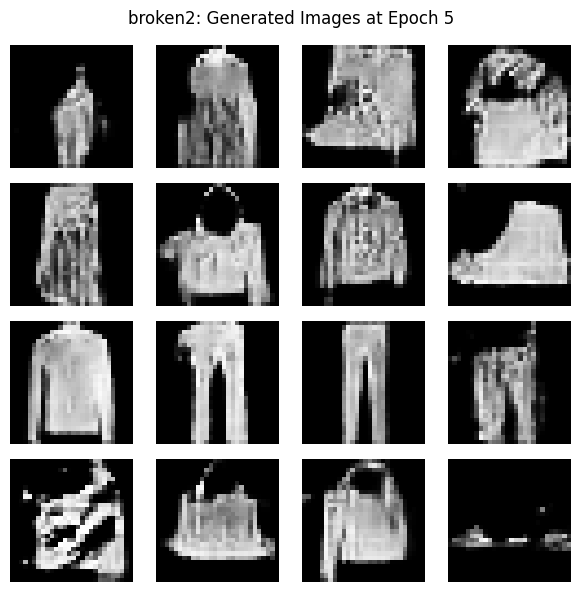

Epoch [6/20]  Discriminator Loss: 0.4437  Generator Loss: 4.2445
Epoch [7/20]  Discriminator Loss: 0.4384  Generator Loss: 4.5008
Epoch [8/20]  Discriminator Loss: 0.3834  Generator Loss: 4.7604
Epoch [9/20]  Discriminator Loss: 0.2734  Generator Loss: 5.1445
Epoch [10/20]  Discriminator Loss: 0.2518  Generator Loss: 5.8311


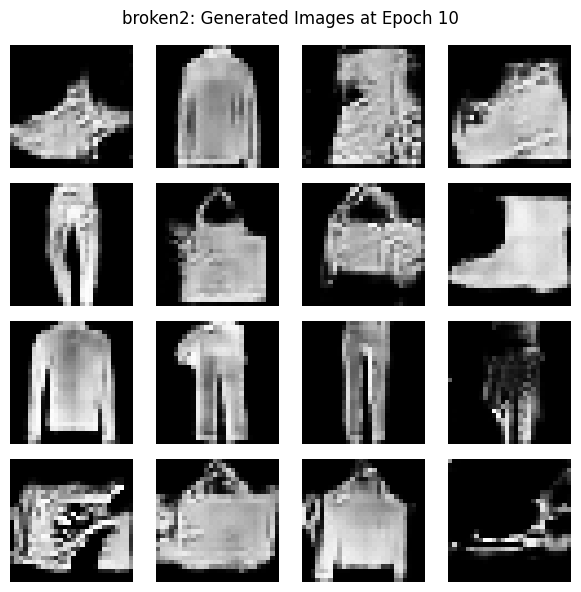

Epoch [11/20]  Discriminator Loss: 0.3177  Generator Loss: 5.6118
Epoch [12/20]  Discriminator Loss: 0.2273  Generator Loss: 5.7084
Epoch [13/20]  Discriminator Loss: 0.3505  Generator Loss: 5.5968
Epoch [14/20]  Discriminator Loss: 0.2221  Generator Loss: 6.1163
Epoch [15/20]  Discriminator Loss: 0.2652  Generator Loss: 6.5661


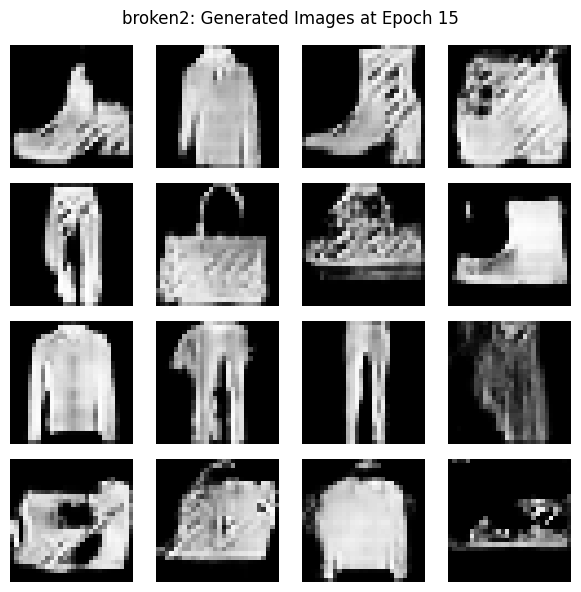

Epoch [16/20]  Discriminator Loss: 0.2541  Generator Loss: 6.0351
Epoch [17/20]  Discriminator Loss: 0.2138  Generator Loss: 6.4741
Epoch [18/20]  Discriminator Loss: 0.2361  Generator Loss: 6.5222
Epoch [19/20]  Discriminator Loss: 0.1989  Generator Loss: 6.6072
Epoch [20/20]  Discriminator Loss: 0.0985  Generator Loss: 7.3983


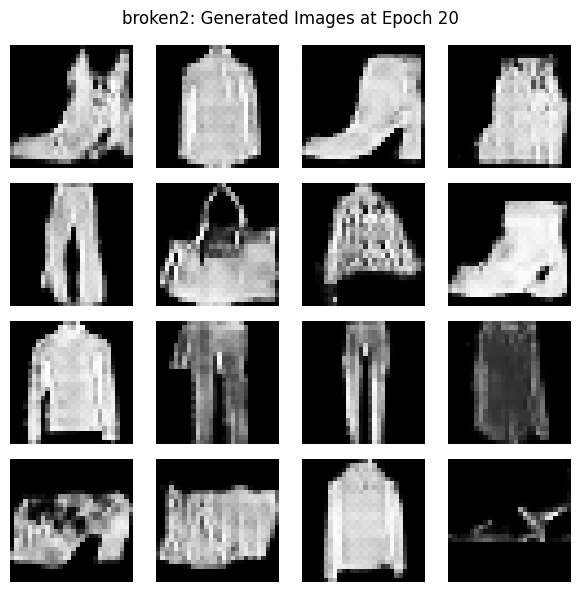

In [15]:
G_losses_broken2, D_losses_broken2 = train_gan(
    generator_broken2,
    discriminator_broken2,
    lr=BROKEN_LR_2,
    real_label_value=1.0,
    run_name="broken2"
)

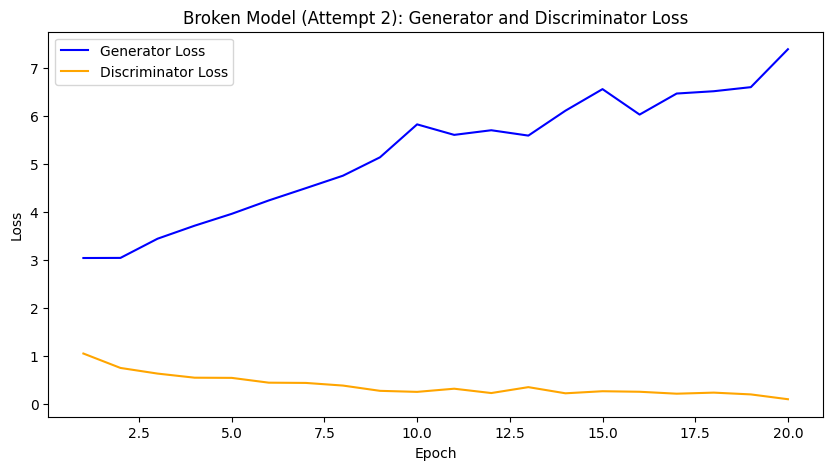

In [16]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, EPOCHS+1), G_losses_broken2, label='Generator Loss',     color='blue')
plt.plot(range(1, EPOCHS+1), D_losses_broken2, label='Discriminator Loss', color='orange')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Broken Model (Attempt 2): Generator and Discriminator Loss')
plt.legend()
plt.show()

### Broken Output (Final Result of the Broken Model, Epoch 20)

The model from Step 6B is used as the broken model for the rest of the assignment.

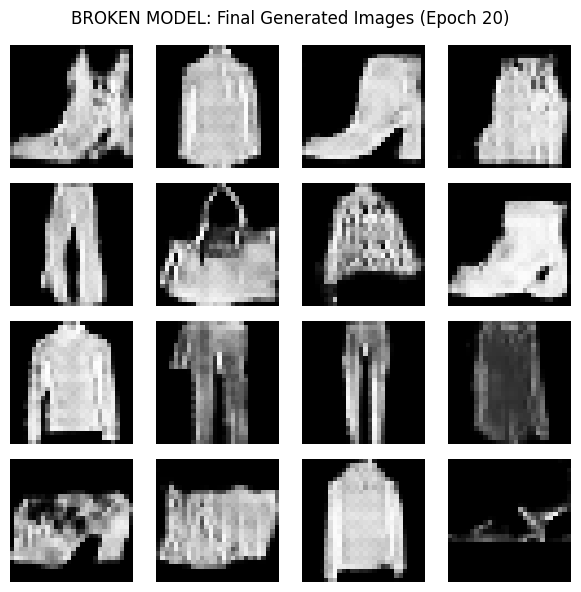

In [17]:
generator_broken2.eval()
with torch.no_grad():
    broken_final = generator_broken2(FIXED_NOISE)

show_grid(broken_final, 'BROKEN MODEL: Final Generated Images (Epoch 20)')

## Step 7: Improving the Model with Label Smoothing

The same reduced generator (no BatchNorm) and the same learning rate of 0.005 are used again, so the only difference from the broken model is label smoothing. In the broken run, the discriminator was trained with the real label as 1.0. Here the real label is set to 0.9. This stops the discriminator from becoming overconfident, so the generator keeps getting a useful learning signal.

Epoch [1/20]  Discriminator Loss: 1.1656  Generator Loss: 2.7093
Epoch [2/20]  Discriminator Loss: 0.9227  Generator Loss: 2.6422
Epoch [3/20]  Discriminator Loss: 0.7863  Generator Loss: 3.0210
Epoch [4/20]  Discriminator Loss: 0.7045  Generator Loss: 3.3721
Epoch [5/20]  Discriminator Loss: 0.6853  Generator Loss: 3.4939


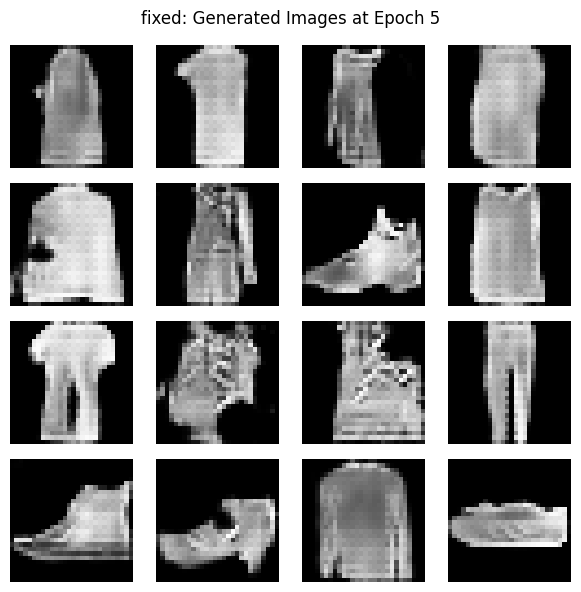

Epoch [6/20]  Discriminator Loss: 0.6455  Generator Loss: 3.6711
Epoch [7/20]  Discriminator Loss: 0.6070  Generator Loss: 3.8823
Epoch [8/20]  Discriminator Loss: 0.5818  Generator Loss: 4.0367
Epoch [9/20]  Discriminator Loss: 0.5630  Generator Loss: 4.2236
Epoch [10/20]  Discriminator Loss: 0.7282  Generator Loss: 3.6904


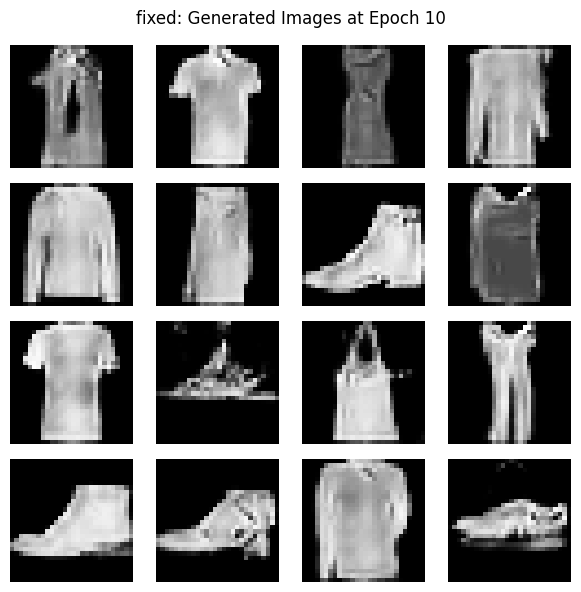

Epoch [11/20]  Discriminator Loss: 0.5274  Generator Loss: 4.1497
Epoch [12/20]  Discriminator Loss: 0.5795  Generator Loss: 4.0399
Epoch [13/20]  Discriminator Loss: 0.5036  Generator Loss: 4.4541
Epoch [14/20]  Discriminator Loss: 0.5763  Generator Loss: 4.2964
Epoch [15/20]  Discriminator Loss: 0.5054  Generator Loss: 4.3585


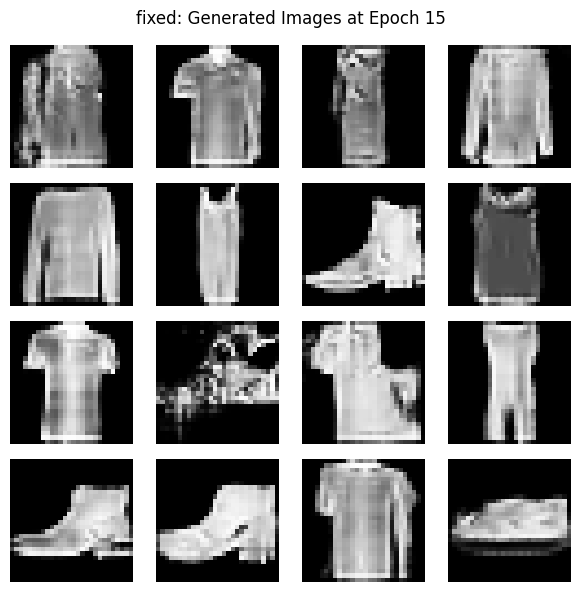

Epoch [16/20]  Discriminator Loss: 0.4758  Generator Loss: 4.6793
Epoch [17/20]  Discriminator Loss: 0.5327  Generator Loss: 4.5071
Epoch [18/20]  Discriminator Loss: 0.6077  Generator Loss: 4.3045
Epoch [19/20]  Discriminator Loss: 0.5123  Generator Loss: 4.4088
Epoch [20/20]  Discriminator Loss: 0.4931  Generator Loss: 4.4059


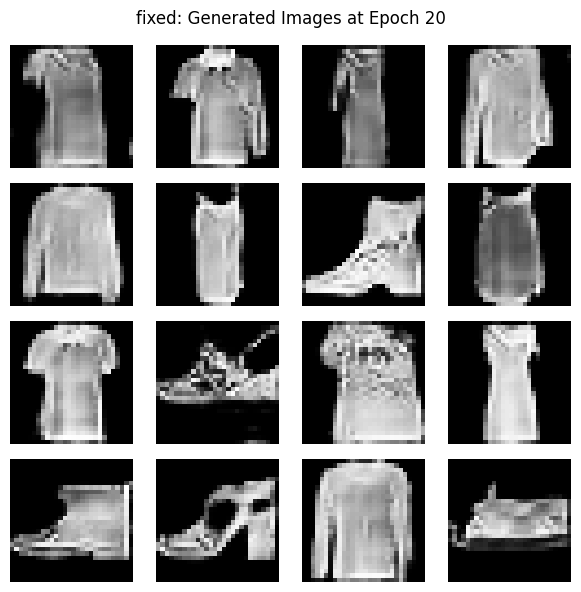

In [18]:
# Fresh models, same architecture as the broken model of Step 6B
generator_fixed = SmallGenerator().to(device)
discriminator_fixed = Discriminator().to(device)

G_losses_fixed, D_losses_fixed = train_gan(
    generator_fixed,
    discriminator_fixed,
    lr=BROKEN_LR_2,            # same high learning rate as the broken model
    real_label_value=0.9,      # label smoothing: real label 0.9 instead of 1.0
    run_name="fixed"
)

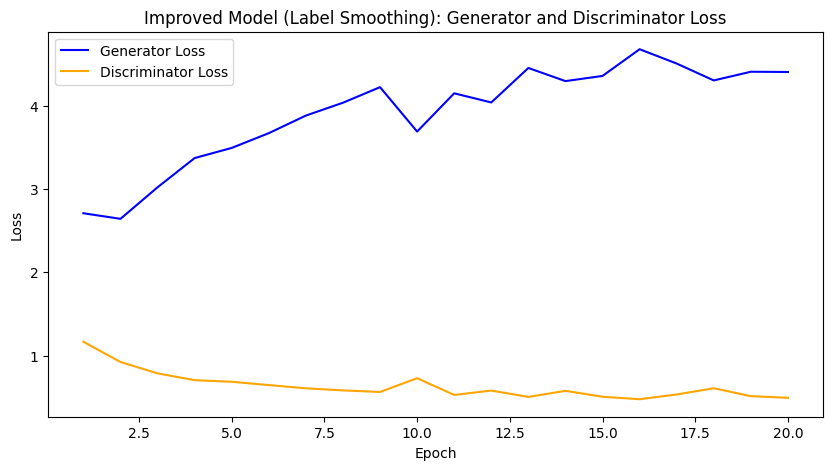

In [19]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, EPOCHS+1), G_losses_fixed, label='Generator Loss',     color='blue')
plt.plot(range(1, EPOCHS+1), D_losses_fixed, label='Discriminator Loss', color='orange')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Improved Model (Label Smoothing): Generator and Discriminator Loss')
plt.legend()
plt.show()

## Step 8: Comparing the Broken and the Improved Model

Both models are shown side by side using the same fixed noise, followed by a comparison of their loss curves.

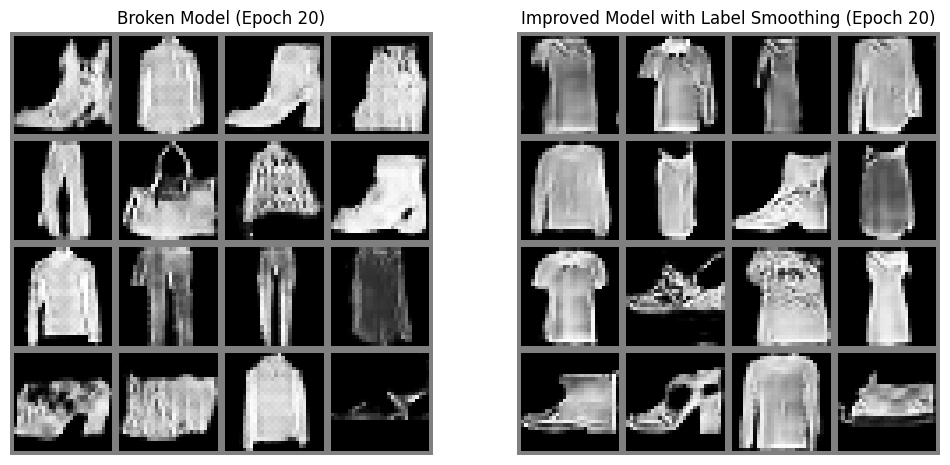

In [20]:
def make_mosaic(images):
    imgs = (images.squeeze(1).cpu().numpy() + 1) / 2    # (16, 28, 28), back to [0,1]
    tiles = [np.pad(imgs[i], 1, constant_values=0.5) for i in range(16)]
    rows = [np.concatenate(tiles[r*4:(r+1)*4], axis=1) for r in range(4)]
    return np.concatenate(rows, axis=0)

generator_broken2.eval()
generator_fixed.eval()
with torch.no_grad():
    out_broken = generator_broken2(FIXED_NOISE)
    out_fixed  = generator_fixed(FIXED_NOISE)

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(make_mosaic(out_broken), cmap='gray', vmin=0, vmax=1)
plt.title('Broken Model (Epoch 20)')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(make_mosaic(out_fixed), cmap='gray', vmin=0, vmax=1)
plt.title('Improved Model with Label Smoothing (Epoch 20)')
plt.axis('off')
plt.show()

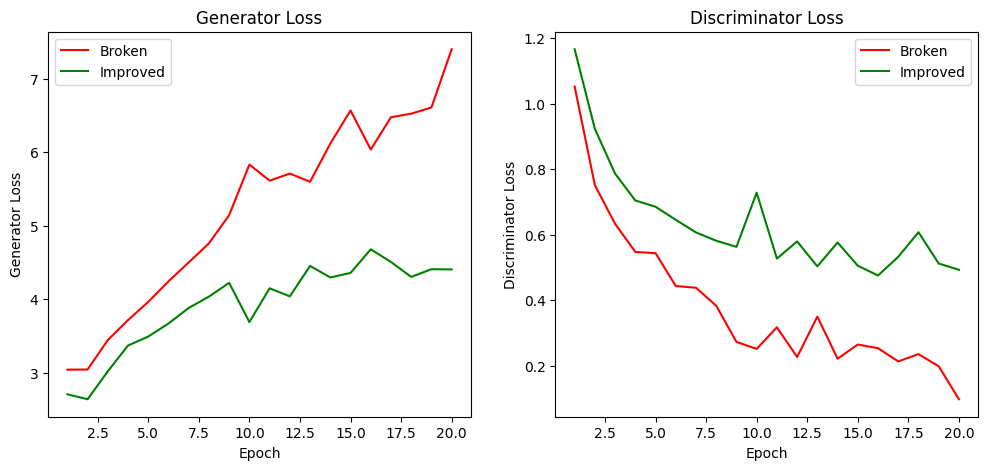

In [21]:
epochs_range = range(1, EPOCHS + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, G_losses_broken2, label='Broken',   color='red')
plt.plot(epochs_range, G_losses_fixed,   label='Improved', color='green')
plt.xlabel('Epoch')
plt.ylabel('Generator Loss')
plt.title('Generator Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, D_losses_broken2, label='Broken',   color='red')
plt.plot(epochs_range, D_losses_fixed,   label='Improved', color='green')
plt.xlabel('Epoch')
plt.ylabel('Discriminator Loss')
plt.title('Discriminator Loss')
plt.legend()
plt.show()

### Improved Output (Final Result of the Improved Model, Epoch 20)

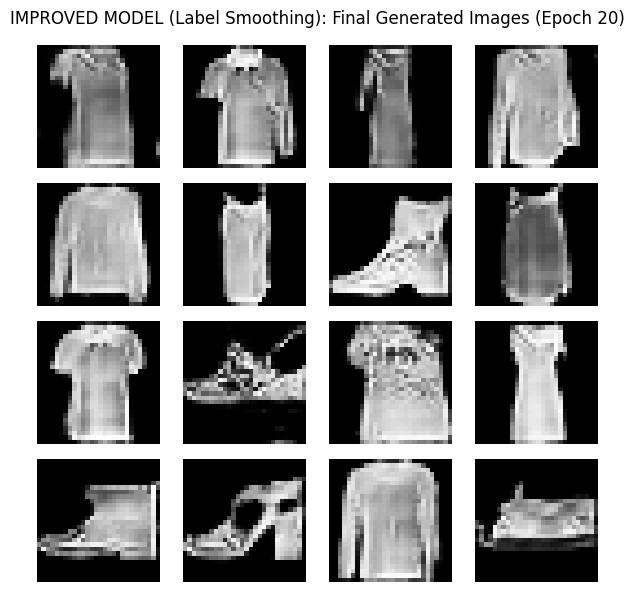

In [22]:
show_grid(out_fixed, 'IMPROVED MODEL (Label Smoothing): Final Generated Images (Epoch 20)')

## Written Explanation

**1. What modification caused the model to perform poorly?**

I made three changes to the working DCGAN from Assignment 4. I removed BatchNorm from the generator, reduced the number of filters in the generator (from 1,067,329 parameters to 143,729), and increased the learning rate from 0.0002 to 0.005. My first attempt, with only BatchNorm removed and a learning rate of 0.001, did not give a clear failure, so I made the model weaker in the second attempt. With these changes the discriminator became much stronger than the generator. The generator loss kept rising from 3.04 to 7.40, while the discriminator loss fell from 1.05 to 0.10.

**2. What did the generated images look like?**

The images were blocky and patchy, and many had messy textures. At epoch 15 the same diagonal stripe pattern appeared on several different items such as boots, trousers and a handbag, which shows the generator was repeating one pattern. By epoch 20 the grid was mostly boots, trousers, tops and bags. The 16 images were still different items, so this was not complete mode collapse, but the quality was clearly worse than the working model, and the repeated stripe pattern shows the generator was falling back on a limited set of patterns.

**3. Which technique did you use to improve the model?**

I used label smoothing. The real label given to the discriminator was changed from 1.0 to 0.9, and everything else (the small generator, the learning rate of 0.005, 20 epochs and the same fixed noise) was kept the same.

**4. Did the solution improve the output? Why?**

Yes, but only partly. The generator loss rose to about 4.4 and then stayed roughly level, instead of climbing to 7.4. The discriminator loss stayed around 0.5 instead of falling to 0.10. The images were smoother, the stripe pattern disappeared, and the grid showed t-shirts, dresses, long sleeve tops, boots, sandals and heels. A likely reason is that with a target of 0.9 the discriminator cannot become fully confident, so it does not push the generator's loss up as much and the generator keeps getting a useful signal. However, some images are still noisy and the generator loss is still higher than in Assignment 4, so the training is not fully stable. Also, I trained each model only once, so this result may not be the same every time.